# Plotting & Analysis for Thesis

Jaisidh Singh

In [1]:
import numpy as np
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
from constants import LRS, BATCH_SIZES, DATA_SCALES, PARAM_SCALES
from utils import Collector

## Utils

In [3]:
sns.set_style(style="whitegrid")

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
## latex rendering
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})

lr_law_palette = "rocket"
gbs_law_palette = "mako"

param_palettes = {
  '20M': '#2166ac',  # blue
  '50M': '#762a83',  # wine/purple
  '150M': '#d73027',  # red
  '300M': '#FFA500',  # orange
}

In [11]:
def qlog2_fit(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # if len(x) < 3:
    #     raise ValueError("Need at least 3 points for quadratic fit")

    # transform to log2 space
    x_log = np.log2(x)

    # quadratic fit
    coeffs = np.polyfit(x_log, y, 2)
    a, b, c = coeffs

    # smooth curve
    x_fit_log = np.linspace(x_log.min(), x_log.max(), 200)
    y_fit = a * x_fit_log**2 + b * x_fit_log + c
    x_fit = 2 ** x_fit_log
    return x_fit, y_fit

## Pure Gated Attention $\rho=0$

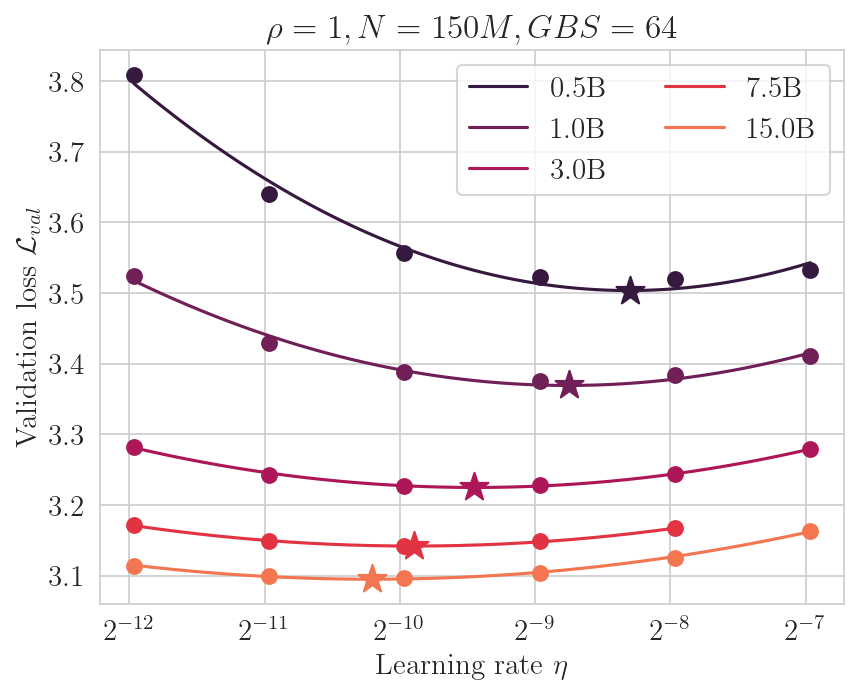

In [18]:
co = Collector("attn")

sns.set_palette(sns.color_palette("rocket"))
for i, d in enumerate(DATA_SCALES):
    slc = co.index(n="150M", d=d, gbs=64)
    xf, yf = qlog2_fit(slc["lr"], slc["val_loss"])
    yf_min = yf.min()
    xf_min = xf[yf.argmin()]
    
    plt.scatter(slc["lr"], slc["val_loss"], c=f"C{i}", s=50)
    plt.plot(xf, yf, label=d, c=f"C{i}")
    plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")

plt.xlabel(r"Learning rate $\eta$")
plt.ylabel(r"Validation loss $\mathcal{L}_{val}$")
plt.xscale("log", base=2)
plt.title(r"$\rho=1, N=150M, GBS=64$")
plt.legend(ncols=2)
plt.show()


In [19]:
# sns.set_palette(sns.color_palette("mako"))
# for i, d in enumerate(DATA_SCALES[:3]):
#     slc = co.index(n="150M", d=d, lr=0.001)
#     xf, yf = qlog2_fit(slc["gbs"], slc["val_loss"])
#     yf_min = yf.min()
#     xf_min = xf[yf.argmin()]
    
#     plt.scatter(slc["gbs"], slc["val_loss"], c=f"C{i}", s=50)
#     plt.plot(xf, yf, label=d, c=f"C{i}")
#     plt.scatter(xf_min, yf_min, marker="*", s=200, c=f"C{i}")

# plt.xlabel(r"Batch size")
# plt.ylabel(r"Validation loss $\mathcal{L}_{val}$")
# plt.xscale("log", base=2)
# plt.title(r"$\rho=1, N=150M, LR=0.001$")
# plt.legend(ncols=1)
# plt.show()

## Pure Gated DeltaNet $\rho=1$